# Appendix E.1 - Activity Plots Charts

This notebook is organised as an annotated workbook: each code block is preceded by a short explanation of what it does and which parameters to edit.

## Step 0 - Import CRIM + helper utilities

This cell imports the CRIM `crim_intervals` package and its helper functions used to load/parse scores and to build interval/feature representations later in the notebook.

In [1]:
import crim_intervals
from crim_intervals import * 
from crim_intervals import main_objs
import crim_intervals.visualizations as viz
import pandas as pd
import re
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
# from ipywidgets import interact
# from pandas.io.json import json_normalize
from pyvis.network import Network
from IPython.display import display
import requests
import glob as glob
import os

from collections import Counter

MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    print("created folder : ", MYDIR)
else:
    print(MYDIR, "folder already exists.")
    
MUSDIR = ("Music_Files")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    print("created folder : ", MUSDIR)

else:
    print(MUSDIR, "folder already exists.")

alt.renderers.enable('default')
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"


saved_csv folder already exists.
Music_Files folder already exists.


## Step 1 - Imports for plotting + data handling

Loads the numerical and plotting libraries used to build a **one-colour presence piano-roll** (sustained notes filled) and visualise it with Plotly.

In [2]:
import os
import numpy as np
import pandas as pd
import plotly.express as px


## Step 2 - Configuration: corpus location, piece selection, and display settings

Edit this block to point to your corpus, choose which pieces/movements to plot, and set global display options.

Key parameters:
- `combineUnisons`: merge unison voices before plotting.
- `step`: time-step resolution for the roll (in quarterLength units; e.g., `0.5` = eighth-note grid).
- `bar_interval`: label every *N* bars on the x-axis.
- `ignore_short_rests_qL`: fill silent gaps shorter than this threshold (quarterLength); set to `0` to disable.


In [3]:
combineUnisons = True
step = 0.5                 # grid step in quarterLength units; try 1.0 for cleaner/faster plots
bar_interval = 25          # label bars: 1, 1+N, 1+2N... (e.g., 1, 26, 51...) when N=25
ignore_short_rests_qL = 16.0  # set None to disable; 8.0 = breve in quarterLength units

REL_CORPUS_DIR = "Music_Files/Eton_Corpus"
ABS_CORPUS_DIR = "/Music_Files/Eton_Corpus"
corpus_dir = REL_CORPUS_DIR if os.path.isdir(REL_CORPUS_DIR) else ABS_CORPUS_DIR
if not os.path.isdir(corpus_dir):
    raise FileNotFoundError(f"Couldn't find corpus directory at '{REL_CORPUS_DIR}' or '{ABS_CORPUS_DIR}'")

piece_list = [
    'e2_kellyk_gaude_flore_virginali.musicxml',
    'e5_browne_stabat_mater_dolorosa.musicxml',
    'e35_banester_o_maria_et_elizabeth.musicxml',
    'e50_fawkyner_gaude_rosa_sine_spina.musicxml',
    'e36_horwood_gaude_flore_virginali.musicxml',
    'e17_horwood_salve_regina.musicxml',
    'e26_fayrfax_salve_regina.musicxml',
    'e25_wlyknson_salve_regina_ii.musicxml',
    'e10_sturton_gaude_virgo_mater_cristi.musicxml',
    
    
    
]
paths = [os.path.join(corpus_dir, fn) for fn in piece_list]
missing = [p for p in paths if not os.path.isfile(p)]
if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

model_path = paths[0]
movement_paths = paths[1:]


## Step 3 - Build a sustained presence roll

Defines a helper that converts a score into a time-indexed **presence matrix** (one column per voice). Values are filled so that notes remain “on” for their duration (rather than appearing as point events). This produces a clean, score-like piano-roll suitable for texture/continuity visualisation.

In [4]:
def build_presence_roll(piece, combineUnisons=True, step=0.5):
    notes = piece.notes(combineUnisons=combineUnisons).copy()
    durs  = piece.durations(df=notes, n=1).copy()

    notes.index = pd.to_numeric(notes.index, errors="coerce")
    durs.index  = pd.to_numeric(durs.index, errors="coerce")
    notes = notes.sort_index()
    durs  = durs.sort_index()

    if len(notes.index) == 0:
        return pd.DataFrame()

    latest_end = float(notes.index.max())
    for v in notes.columns:
        onsets = notes[v].dropna().index.to_numpy(dtype=float)
        if onsets.size == 0:
            continue
        vdurs = durs[v].reindex(onsets).fillna(0).to_numpy(dtype=float)
        latest_end = max(latest_end, float(np.max(onsets + vdurs)))

    grid = np.arange(float(notes.index.min()), latest_end + step * 0.5, step)
    presence = pd.DataFrame(index=grid, columns=notes.columns, dtype=float)

    for v in notes.columns:
        s = notes[v].dropna()
        for t0, token in s.items():
            tok = str(token).strip().lower()
            if tok in {"r", "rest", ""}:
                continue

            dur = durs[v].get(t0, np.nan)
            if pd.isna(dur) or dur <= 0:
                idx = int(np.argmin(np.abs(presence.index.to_numpy() - float(t0))))
                presence.iat[idx, presence.columns.get_loc(v)] = 1.0
                continue

            start = float(t0)
            end   = start + float(dur)
            mask = (presence.index >= start) & (presence.index < end)
            presence.loc[mask, v] = 1.0

    return presence

## Step 4 - Optionally fill short rests

Defines a helper that **removes very short gaps** in the presence matrix (e.g., rests shorter than a breve). This is useful when you want the roll to reflect longer-span continuity rather than surface articulation.

The threshold is set by `ignore_short_rests_qL` in quarterLength units.

In [5]:
def fill_short_rests(presence, step, ignore_short_rests_qL):
    """
    Fill silent gaps shorter than ignore_short_rests_qL (in quarterLength units).
    If ignore_short_rests_qL is None, do nothing.
    """
    if ignore_short_rests_qL is None:
        return presence

    max_gap_steps = int(ignore_short_rests_qL / step)
    if max_gap_steps <= 0:
        return presence

    filled = presence.copy()

    for v in filled.columns:
        col = filled[v].copy()
        is_sound = col.notna().to_numpy()

        i = 0
        while i < len(is_sound):
            if not is_sound[i]:
                start = i
                while i < len(is_sound) and not is_sound[i]:
                    i += 1
                gap_len = i - start

                # fill gap if shorter than threshold
                if gap_len <= max_gap_steps:
                    col.iloc[start:i] = 1.0
            else:
                i += 1

        filled[v] = col

    return filled

## Step 5 - Bar-number (measure) ticks

Extracts measure boundaries from the underlying `music21` stream and converts them into x-axis tick positions. This allows the roll to display **bar numbers every N bars** even though the roll is built on a continuous time grid.

In [6]:
def _get_m21_score(piece):
    """
    Try common attribute names used by CRIM Intervals objects to expose the music21 stream.
    """
    for attr in ("score", "_score", "stream", "_stream", "s"):
        if hasattr(piece, attr):
            sc = getattr(piece, attr)
            if callable(sc):
                try:
                    sc = sc()
                except TypeError:
                    pass
            if sc is not None:
                return sc
    return None

def get_bar_ticks_m21(piece, bar_interval=25):
    """
    Returns (tickvals, ticktext) from music21 Measure objects.
    Labels bar 1, then every N bars thereafter.
    """
    sc = _get_m21_score(piece)
    if sc is None:
        return [], []

    try:
        parts = list(sc.parts) if hasattr(sc, "parts") else []
    except Exception:
        parts = []

    if not parts:
        return [], []

    chosen_part = None
    for p in parts:
        try:
            if len(p.getElementsByClass("Measure")) > 0:
                chosen_part = p
                break
        except Exception:
            continue
    if chosen_part is None:
        return [], []

    tickvals, ticktext = [], []
    for m in chosen_part.getElementsByClass("Measure"):
        try:
            bar_no = int(getattr(m, "number", None))
        except Exception:
            continue

        if not (bar_no == 1 or ((bar_no - 1) % bar_interval == 0)):
            continue

        try:
            off = float(m.getOffsetInHierarchy(sc))
        except Exception:
            try:
                off = float(m.offset)
            except Exception:
                continue

        tickvals.append(off)
        ticktext.append(str(bar_no))

    return tickvals, ticktext

## Step 6 - Plotting function

Defines `plot_presence(...)`, which:
1) builds the presence roll,
2) optionally fills short rests,
3) computes bar-number ticks,
4) plots the result as a single-colour heatmap with the **lowest voice at the bottom**.

This is the main function you’ll call for each piece/movement.

In [7]:
def plot_presence(piece, title, combineUnisons=True, step=0.5, bar_interval=25, ignore_short_rests_qL=4.0):
    presence = build_presence_roll(piece, combineUnisons=combineUnisons, step=step)
    if presence.empty:
        print("No data to plot.")
        return

    # smooth over short rests if requested
    presence = fill_short_rests(presence, step, ignore_short_rests_qL)

    # IMPORTANT: reverse voice order so lowest voice ends up at BOTTOM when origin='lower'
    plot_df = presence.T.iloc[::-1]

    fig = px.imshow(
        plot_df,
        aspect="auto",
        origin="lower",
        color_continuous_scale=[[0, "#1f77b4"], [1, "#1f77b4"]],  # single colour
        labels=dict(x="Bar number", y="Voice", color="Presence"),
        title=title
    )
    fig.update_coloraxes(showscale=False)

    tickvals, ticktext = get_bar_ticks_m21(piece, bar_interval=bar_interval)
    if tickvals:
        fig.update_xaxes(tickmode="array", tickvals=tickvals, ticktext=ticktext)
    else:
        fig.update_xaxes(title_text=f"Time (quarterLength), step={step} (bar labels unavailable from measures)")

    fig.update_layout(height=450)
    fig.show()

## Step 7 - Run the analysis for your model + selected movements

Loads the chosen score(s) and calls `plot_presence(...)` for each movement/piece in `piece_list`. Edit the paths and list above, then run this cell.

MODEL METADATA
{'title': 'Gaude Flore Virginali', 'composer': 'Hugh Kellyk', 'date': None}


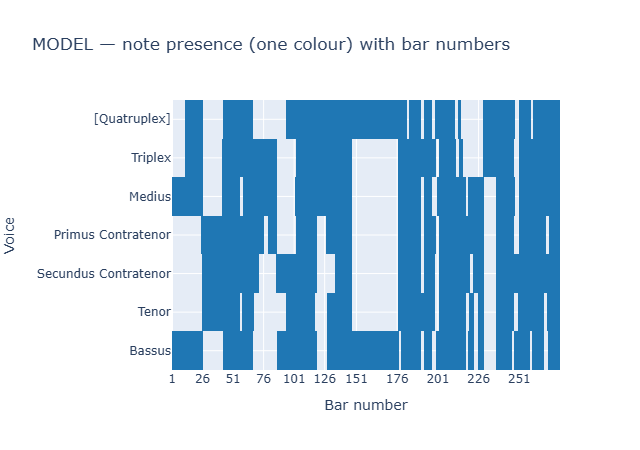


MOVEMENT METADATA
{'title': 'Stabat mater dolorosa', 'composer': 'John Browne', 'date': None}


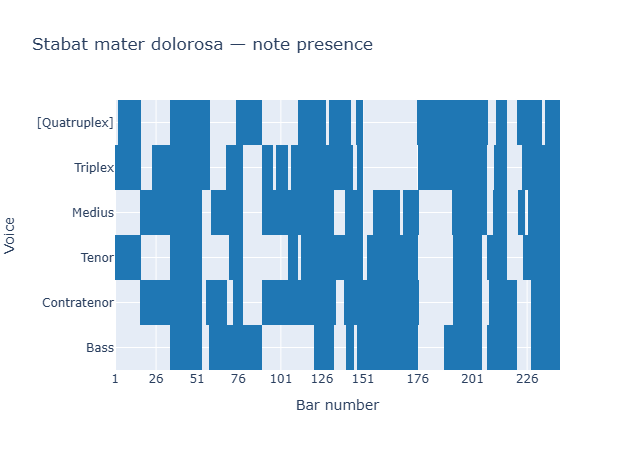


MOVEMENT METADATA
{'title': 'O Maria et Elizabeth', 'composer': 'Gilbert Banester', 'date': None}


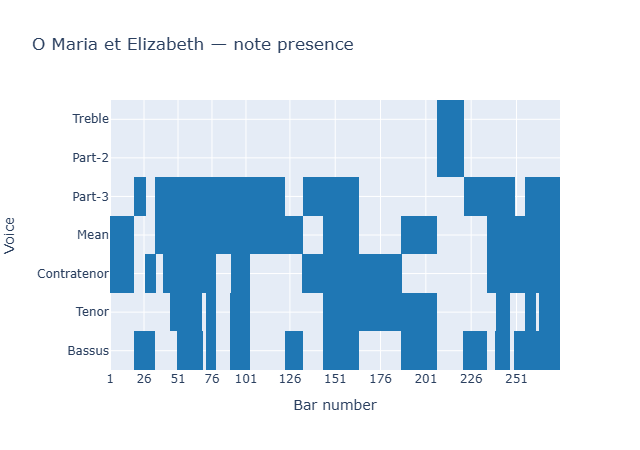


MOVEMENT METADATA
{'title': 'Gaude Rosa Sine Spina', 'composer': '[Richard] Fawkyner', 'date': None}


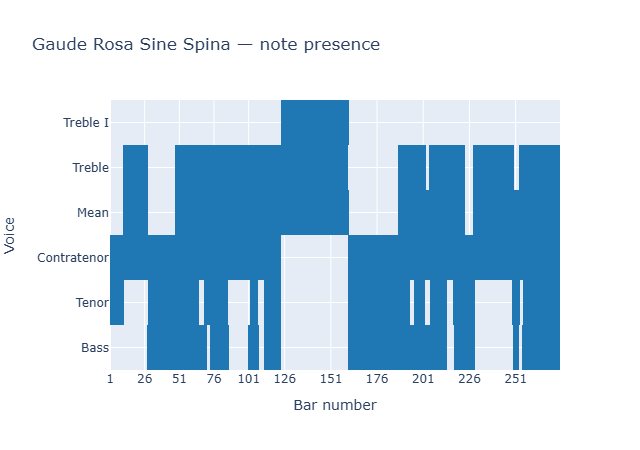


MOVEMENT METADATA
{'title': 'Gaude Flore Virginali', 'composer': 'William Horwood', 'date': None}


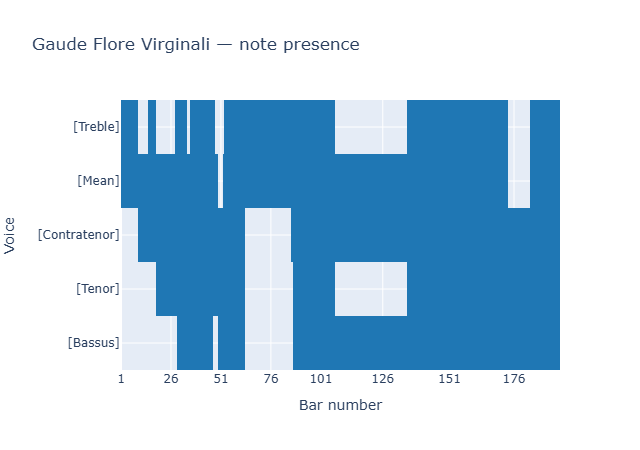


MOVEMENT METADATA
{'title': 'Salve Regina', 'composer': 'William Horwood\ned. Michael Winter', 'date': None}


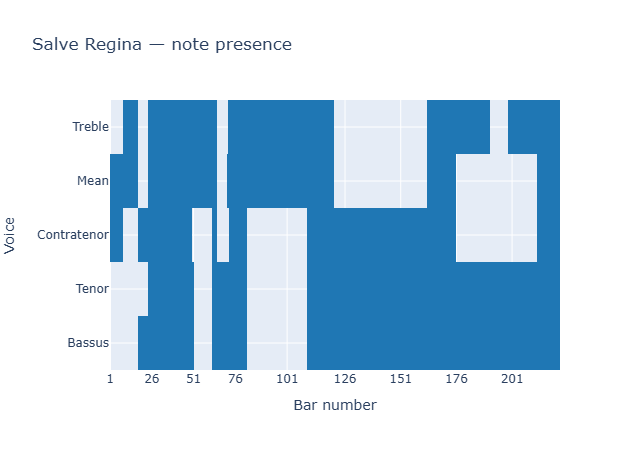


MOVEMENT METADATA
{'title': 'Salve Regina', 'composer': 'Robert Fayrfax', 'date': None}


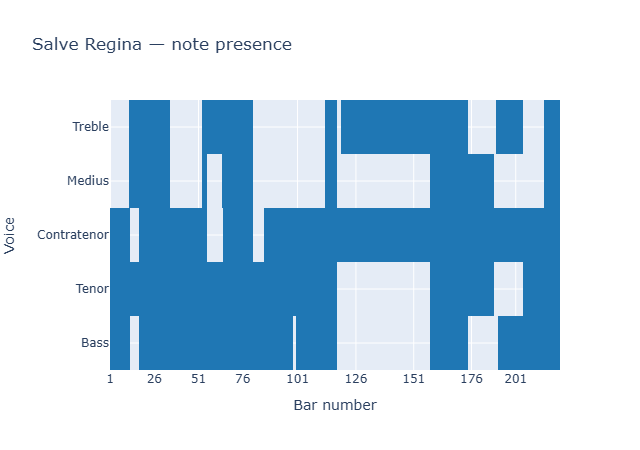


MOVEMENT METADATA
{'title': 'Salve Regina II', 'composer': 'Robert Wylkynson', 'date': None}


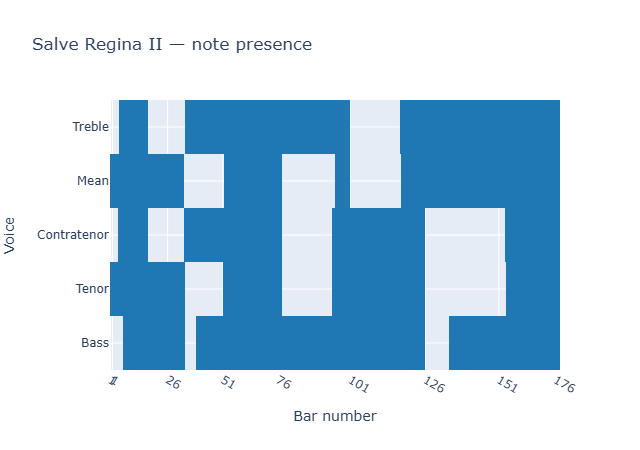


MOVEMENT METADATA
{'title': 'Gaude virgo mater Christi', 'composer': 'Edmund Sturton', 'date': None}


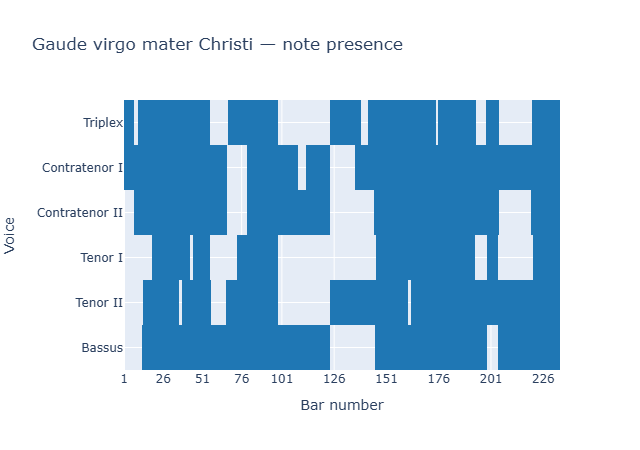

In [8]:
model = importScore(model_path)
print("MODEL METADATA")
print(model.metadata)
plot_presence(
    model,
    "MODEL — note presence (one colour) with bar numbers",
    combineUnisons=combineUnisons,
    step=step,
    bar_interval=bar_interval,
    ignore_short_rests_qL=ignore_short_rests_qL
)

for p in movement_paths:
    mv = importScore(p)
    print("\nMOVEMENT METADATA")
    print(mv.metadata)
    plot_presence(
        mv,
        mv.metadata.get("title", "Movement") + " — note presence",
        combineUnisons=combineUnisons,
        step=step,
        bar_interval=bar_interval,
        ignore_short_rests_qL=ignore_short_rests_qL
    )


In [11]:
!jupyter nbconvert --to html "Activity_Map_Charts_Annotated.ipynb"

[NbConvertApp] Converting notebook Activity_Map_Charts_Annotated.ipynb to html
[NbConvertApp] Writing 2331284 bytes to Activity_Map_Charts_Annotated.html
